# Predicting Car Priece

## Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/lucja/Desktop/Machine Learning/Assignment1/Cars.csv")

df.shape

(8128, 13)

In [2]:
#first 5 rows of the DataFrame
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
# overview of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [4]:
# count the number of missing values per column
df.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [5]:
# delete duplicates 
print("Amount of duplicates: ", df.duplicated().sum())
df = df.drop_duplicates()

# returns (number of rows, number of columns)
df.shape

Amount of duplicates:  1202


(6926, 13)

## Feature engineering
Because the data contains text with units (e.g. mileage, engine) that needs to be converted into numbers, as well as outliers (Test Drive Cars) and inconsistent categories (CNG/LPG) that need to be removed, I need to apply feature engineering.

In [6]:
# mapping - each text category is assigned a number
owner_map = {'First Owner':1, 'Second Owner':2, 'Third Owner':3,
             'Fourth & Above Owner':4, 'Test Drive Car':5}
df['owner'] = df['owner'].map(owner_map)

# we keep only the rows where fuel is not CNG or LPG
df = df[~df['fuel'].isin(['CNG','LPG'])]

# we split the text by space, take only the number, and convert it to float instead of text
df['mileage'] = df['mileage'].str.split(' ').str[0].astype(float)


df['engine'] = df['engine'].str.split(' ').str[0].astype(float)

df['max_power'] = df['max_power'].str.split(' ').str[0].replace('', np.nan).astype(float)

# we split the column name by space and take the first word as a new column name
df['brand'] = df['name'].str.split(' ').str[0]
df = df.drop(columns=['name'])

df = df.drop(columns=['torque'])

# h) usuń Test Drive Cars
df = df[df['owner'] != 5]

# checking the shape after Feature Engineering 
print(df.shape)
df.head()

(6827, 12)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


## Preprocessing 

In [7]:
print("Missing values before imputation:")
print(df.isna().sum())

Missing values before imputation:
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
brand              0
dtype: int64


In [8]:
# we fill missing values in numeric columns with the median, since median is robust to outliers unlike the mean
for col in ['mileage', 'engine', 'max_power', 'seats']:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:")
print(df.isna().sum())


Missing values after imputation:
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64


## Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# LabelEncoder converts binary categories into 0/1, since there's no risk of implying false order with only two categories
df['transmission'] = le.fit_transform(df['transmission'])
df['seller_type']  = le.fit_transform(df['seller_type'])

# One-hot encoding is used for fuel and brand instead, since they have more categories and numeric encoding would 
# wrongly imply an order between them
# drop_first=True avoids redundancy by dropping one category per feature
df = pd.get_dummies(df, columns=['fuel', 'brand'], drop_first=True)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (6827, 42)


,year,selling_price,km_driven,seller_type,transmission,owner,mileage,engine,max_power,seats,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,1,1,1,23.40,1248.0,74.00,5.0,...,False,False,False,False,False,False,False,False,False,False
1,2014,370000,120000,1,1,2,21.14,1498.0,103.52,5.0,...,False,False,False,False,False,True,False,False,False,False
2,2006,158000,140000,1,1,3,17.70,1497.0,78.00,5.0,...,False,False,False,False,False,False,False,False,False,False
3,2010,225000,127000,1,1,1,23.00,1396.0,90.00,5.0,...,False,False,False,False,False,False,False,False,False,False
4,2007,130000,120000,1,1,1,16.10,1298.0,88.20,5.0,...,False,False,False,False,False,False,False,False,False,False


## Exploratory Data Analysis

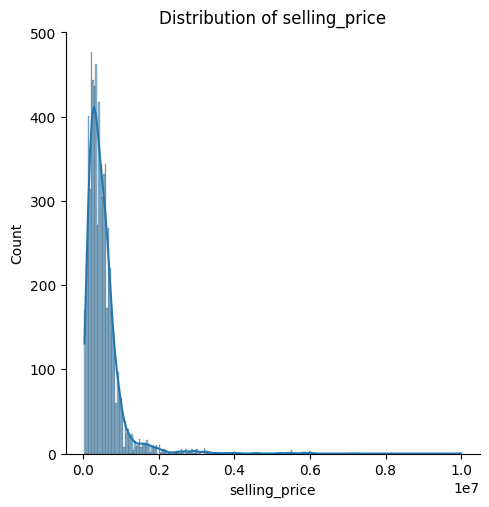

In [10]:
# plot the distribution of selling_price to check its shape, expected to be right-skewed (long tail of expensive cars),
# which justifies applying a log transform later
sns.displot(df['selling_price'], kde=True)
plt.title('Distribution of selling_price')
plt.show()

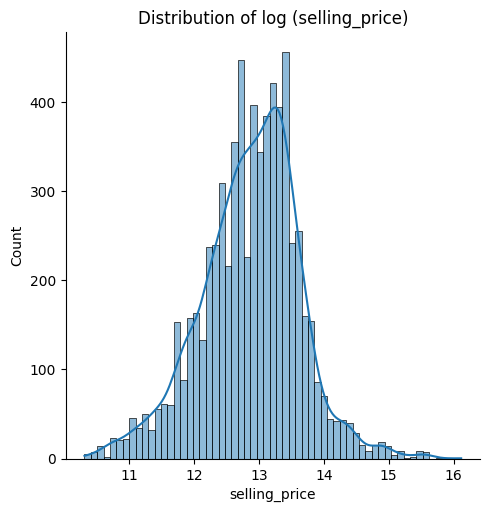

In [11]:
# plot the distribution of log-transformed selling_price, compared to the previous plot, this should look 
# more symmetric/normal-shaped, confirming that the log transform helps stabilize the target's distribution
sns.displot(np.log(df['selling_price']), kde=True)
plt.title('Distribution of log (selling_price)')
plt.show()

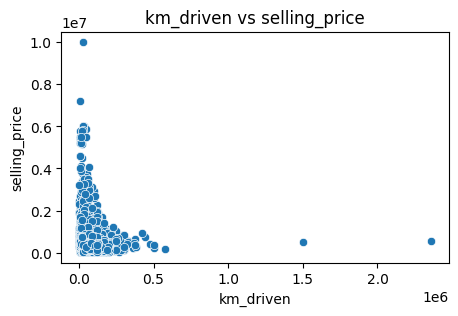

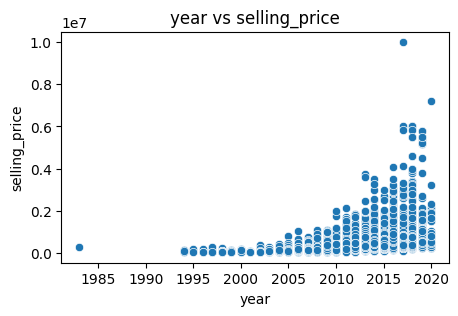

In [12]:
# scatter plots to visually check the relationship between selling_price
# and two key numeric features: expecting price to decrease with km_driven and increase with year
for col in ['km_driven', 'year']:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[col], y=df['selling_price'])
    plt.title(f'{col} vs selling_price')
    plt.show()

In [13]:
# calculate correlation of every feature with selling_price and sort it, to see at a glance which features 
# are most linearly related to price
corr_with_price = df.corr()['selling_price'].sort_values(ascending=False)
print(corr_with_price)

selling_price          1.000000
max_power              0.693212
engine                 0.451093
year                   0.438621
brand_BMW              0.369113
brand_Mercedes-Benz    0.281290
brand_Volvo            0.251555
brand_Audi             0.199301
brand_Toyota           0.171750
seats                  0.168928
brand_Jaguar           0.150339
brand_Jeep             0.142252
brand_Lexus            0.110336
brand_Land             0.090726
brand_Mahindra         0.066771
brand_Isuzu            0.058826
brand_MG               0.052214
brand_Kia              0.035268
brand_Honda            0.024016
brand_Mitsubishi       0.019027
brand_Force            0.015405
brand_Skoda            0.014718
brand_Ashok           -0.005192
brand_Ford            -0.006319
brand_Volkswagen      -0.010588
brand_Opel            -0.010718
brand_Peugeot         -0.010980
brand_Nissan          -0.012552
brand_Daewoo          -0.018196
brand_Renault         -0.023700
brand_Fiat            -0.035287
brand_Da

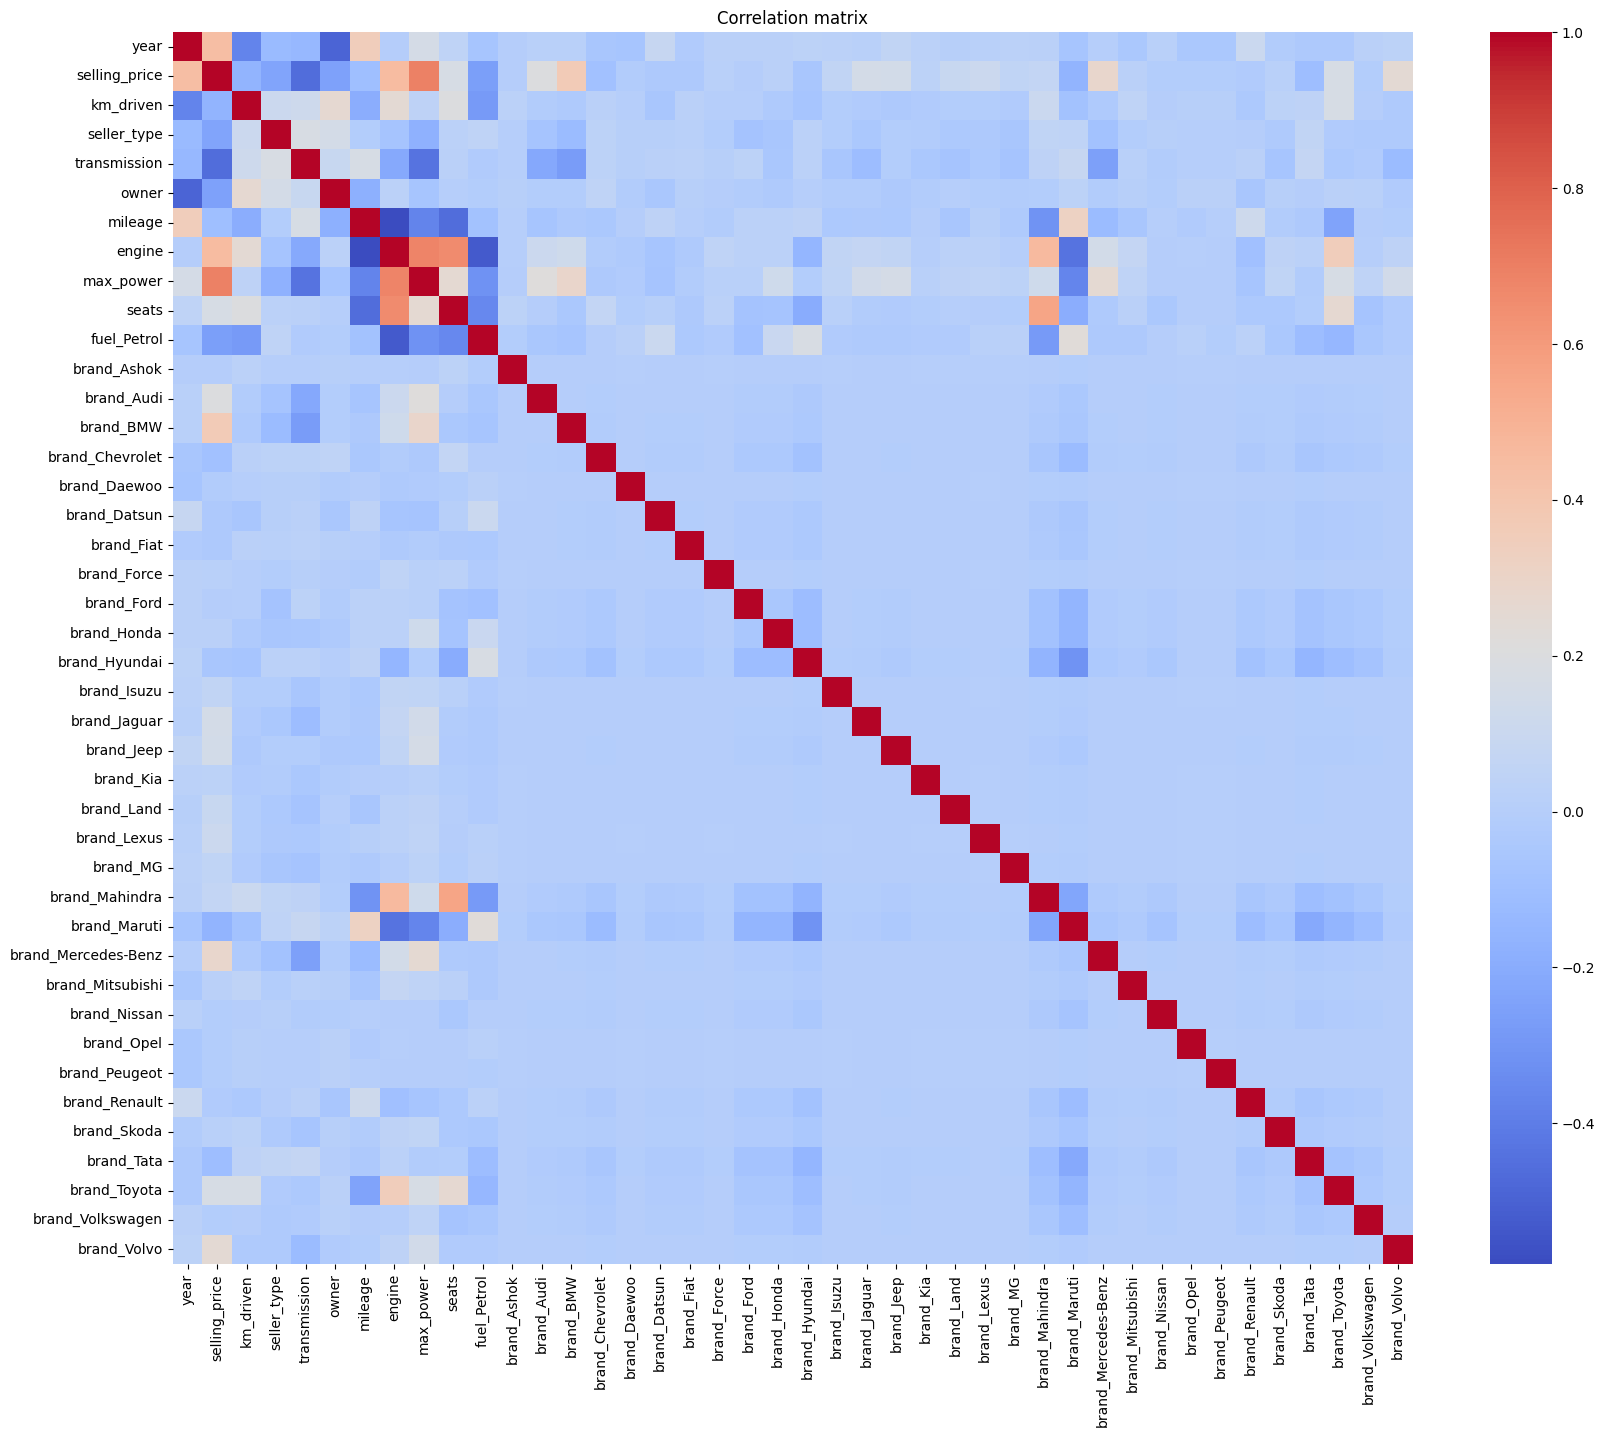

In [14]:
# correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

## Train/test

In [15]:
# separate the target (y) from the features (X): y is the log-transformed price we want to predict,
# X is everything else the model will use to make that prediction

y = np.log(df['selling_price'])
X = df.drop(columns=['selling_price'])
X.shape, y.shape

((6827, 41), (6827,))

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=999)
X_train.shape, X_test.shape

((5461, 41), (1366, 41))

## Modeling 

In [17]:
# compare three regression algorithms using 5-fold cross-validation,
# to see which one generalizes best before tuning it further with GridSearch

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

lr = LinearRegression()
rf = RandomForestRegressor(random_state=999)
sv = SVR()

models = [lr, rf, sv]
kfold = KFold(n_splits=5, shuffle=True, random_state=999)

for model in models:
    score = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    print(f"{model.__class__.__name__}: mean R2 = {score.mean():.4f}, std = {score.std():.4f}")

LinearRegression: mean R2 = 0.8730, std = 0.0094
RandomForestRegressor: mean R2 = 0.9034, std = 0.0076
SVR: mean R2 = 0.1690, std = 0.0198


## Grid Search

In [18]:
# it tests every combination of n_estimators, max_depth, and min_samples_split via 5-fold
# cross-validation, then refits the best combination on the full training set
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor(random_state=999)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(model, param_grid, scoring='r2', cv=kfold, refit=True, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best R2:", grid.best_score_)

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best R2: 0.9060434132949784


## Testing 

In [19]:
# evaluate the tuned model on the held-out test set, predictions and true values must be converted back
# from log scale with np.exp() before comparing them, since the model was trained on log(selling_price)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pred_y_log = grid.predict(X_test)

pred_y = np.exp(pred_y_log)
y_test_original = np.exp(y_test)

# we compute metrics on the original price scale, not the log scale
r2 = r2_score(y_test_original, pred_y)
mse = mean_squared_error(y_test_original, pred_y)
mae = mean_absolute_error(y_test_original, pred_y)
rmse = np.sqrt(mse)

print(f"R2:   {r2:.4f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")

R2:   0.9358
MSE:  19,352,648,489.97
RMSE: 139,113.80
MAE:  71,779.48


## Vizualization 

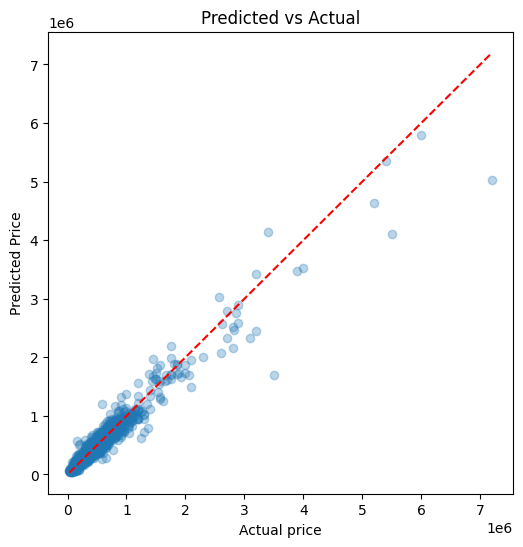

In [20]:
# visualize predicted vs actual prices: points closer to the red diagonal line
# indicate more accurate predictions, the diagonal represents a perfect prediction

plt.figure(figsize=(6,6))
plt.scatter(y_test_original, pred_y, alpha=0.3)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()], 'r--')
plt.xlabel('Actual price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual')
plt.show()

## Feature Importance

           features  importance
0              year    0.496107
7         max_power    0.333133
6            engine    0.057851
1         km_driven    0.025792
5           mileage    0.022363
37       brand_Tata    0.015945
8             seats    0.008949
4             owner    0.007168
9       fuel_Petrol    0.005722
38     brand_Toyota    0.004351
13  brand_Chevrolet    0.003704
28   brand_Mahindra    0.003014
3      transmission    0.002033
29     brand_Maruti    0.002016
18       brand_Ford    0.001714


<Figure size 800x600 with 0 Axes>

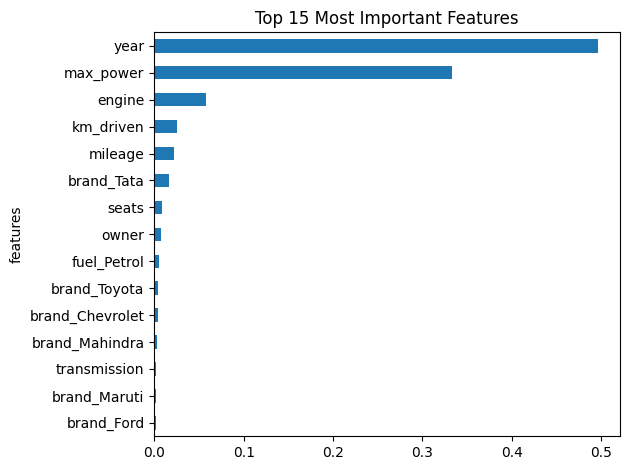

In [21]:
# extract feature importance from the tuned Random Forest model to see which features contributed most to its predictions
# unlike linear correlation,this also captures non-linear relationships the model learned
importances = grid.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({'features': X.columns, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

print(feat_imp.head(15))

# sort ascending here so the most important feature appears at the top of the horizontal bar chart
plt.figure(figsize=(8,6))
feat_imp.head(15).sort_values('importance').plot.barh(x='features', y='importance', legend=False)
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

## Saving the model 

In [22]:
import pickle
import os

os.makedirs('app/code/model', exist_ok=True)
pickle.dump(grid, open('app/code/model/car_price_model.pkl', 'wb'))
pickle.dump(X.columns.tolist(), open('app/code/model/model_columns.pkl', 'wb'))

print("Model saved")

Model saved


## App

In [23]:
# calculate "typical" values (median for numeric, most common for categorical) for each feature,
# these are used by the web app to fill in any fields the user leaves blank
defaults = {
    'year': int(df['year'].median()),
    'km_driven': int(df['km_driven'].median()),
    'mileage': float(df['mileage'].median()),
    'engine': float(df['engine'].median()),
    'max_power': float(df['max_power'].median()),
    'seats': float(df['seats'].median()),
    'owner': int(df['owner'].median()),
    'transmission': int(df['transmission'].mode()[0]),
    'seller_type': int(df['seller_type'].mode()[0]),
}
print(defaults)


{'year': 2014, 'km_driven': 70000, 'mileage': 19.4, 'engine': 1248.0, 'max_power': 81.86, 'seats': 5.0, 'owner': 1, 'transmission': 1, 'seller_type': 1}


In [24]:
# we save these default values to a file so the Dash app can load and use them
import pickle
import os
os.makedirs('app/code/model', exist_ok=True)
pickle.dump(defaults, open('app/code/model/defaults.pkl', 'wb'))
print("Defaults saved")

Defaults saved


## Report: Car Price Prediction


**Feature importance:** Based on the Random Forest feature importance analysis, year and 
max_power were by far the most important features in predicting car price, together 
accounting for over 80% of the model's decision-making. Newer  cars tend to have modern technology, less wear, and remaining warranty, while a more  powerful engine is generally associated with higher-end, more expensive vehicles. 
engine size was moderately important, likely because it correlates strongly with max_power. 
Features like km_driven and mileage had a smaller but non-negligible effect, reflecting 
that heavily used cars tend to sell for less. On the other hand, individual brand indicators 
(e.g. brand_Maruti, brand_Ford), transmission, owner, and fuel_Petrol contributed 
very little individually since one-hot encoded brand columns each only 
capture a small, specific subset of the data, and their effect is likely already captured 
indirectly through correlated features like engine size and power.

**Model comparison:** Among the three baseline models tested with cross-validation, Random 
Forest Regressor performed best (mean R² = 0.90), followed closely by Linear Regression 
(mean R² = 0.87), while Support Vector Regression performed very poorly (mean R² = 0.17). 


**Final results:** After tuning Random Forest with GridSearchCV (best parameters: 
max_depth=20, min_samples_split=5, n_estimators=200), the final model achieved an R² of 
0.9358 on the held-out test set, meaning it explains about 94% of the variance in car 
selling prices. The Mean Absolute Error (MAE) of approximately 71,779 indicates that, on 
average, predictions are off by this amount in the original price units, which is reasonable 
given that selling prices in the dataset range widely, from tens of thousands to several 
million.